In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, SimpleRNN, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)

    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)

    return series[..., np.newaxis].astype(np.float32)

# Data
np.random.seed(0)
n_steps = 50
series = generate_time_series(10000, n_steps + 1)

X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test,  y_test  = series[9000:, :n_steps], series[9000:, -1]


model_linear = Sequential([
    Input(shape=(50, 1)),
    Flatten(),
    Dense(1)
])


model_simple_rnn = Sequential([
    Input(shape=(50, 1)),
    SimpleRNN(1)
])

model_deep_rnn = Sequential([
    Input(shape=(50, 1)),
    SimpleRNN(20, return_sequences=True),
    SimpleRNN(20, return_sequences=True),
    SimpleRNN(1)
])

In [3]:

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

model_linear.compile(loss="mse", optimizer=Adam(0.001), metrics=["mse"])
model_simple_rnn.compile(loss="mse", optimizer=Adam(0.001), metrics=["mse"])
model_deep_rnn.compile(loss="mse", optimizer=Adam(0.001), metrics=["mse"])


history_linear = model_linear.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop],
    verbose=0
)

history_simple_rnn = model_simple_rnn.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop],
    verbose=0
)

history_deep_rnn = model_deep_rnn.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stop],
    verbose=0
)

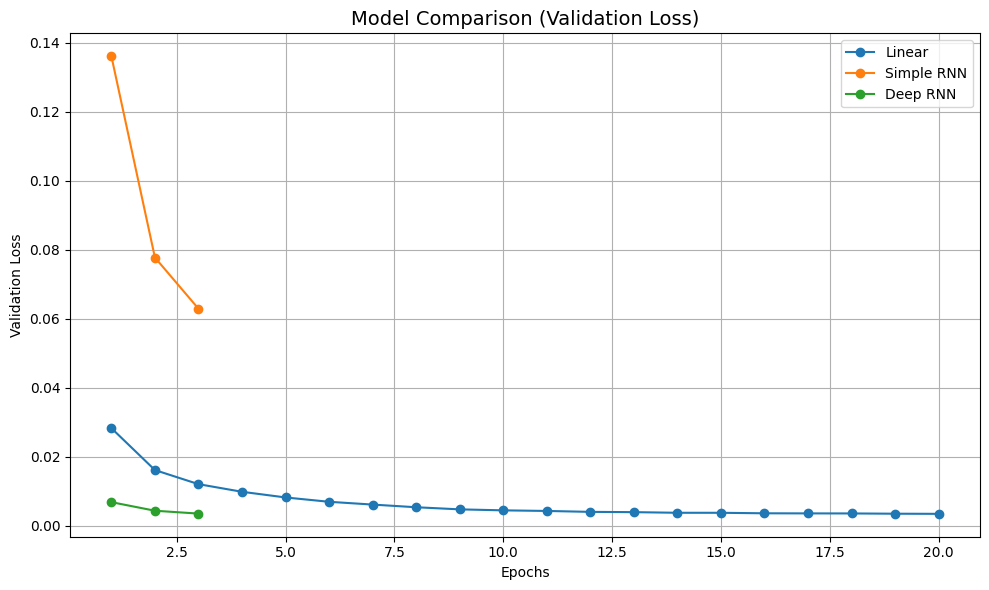

In [5]:

def plot_comparison(histories, names):
    plt.figure(figsize=(10,6))

    for history, name in zip(histories, names):
        val_loss = history.history["val_loss"]
        epochs = range(1, len(val_loss) + 1)
        plt.plot(epochs, val_loss, marker='o', label=name)

    plt.title("Model Comparison (Validation Loss)", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Validation Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# zavolání
plot_comparison(
    [history_linear, history_simple_rnn, history_deep_rnn],
    ["Linear", "Simple RNN", "Deep RNN"]
)

In [6]:
print("\n=== Model Comparison ===")
print(f"{'Model':<15} {'Test MSE':<10}")

for name, model in models.items():
    loss, mse = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:<15} {mse:.6f}")


=== Model Comparison ===
Model           Test MSE  
Linear          0.003539
Simple RNN      0.127926
Deep RNN        0.007138
